# Customer Churn Prediction Using Machine Learning
# **1. Project Introduction**
Customer Churn refers to the Situation in which a Customer stops using the services of a Company .This Project uses machine learning to predict Whether a Customer is likely to Churn

**2 . Importing the dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix,classification_report


**3. Data loading and understanding**

In [2]:
# load the csv data to a pandas dataframe
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv ")

In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.head()

,omerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['omerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   omerID            7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
pd.set_option("display.max_columns",None)

In [9]:
df.tail()

,omerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.sample(4)

,omerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1113,7627-JKIAZ,Female,0,Yes,No,37,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),78.95,2839.65,Yes
1745,2418-TPEUN,Female,0,Yes,Yes,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.80,1119.9,No
2695,0254-KCJGT,Male,0,Yes,No,52,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),81.40,4354.45,No
3406,6447-EGDIV,Female,0,No,No,31,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.95,683.25,No


In [11]:
df.describe(include="object")

,omerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
df.nunique()

omerID              7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [13]:
#dropping the omerID column this is not required in modeling 
df=df.drop(columns=["omerID"])

In [14]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [15]:
for col in df.columns:
    print(col,df[col].unique())
    print("."*50)

gender ['Female' 'Male']
..................................................
SeniorCitizen [0 1]
..................................................
Partner ['Yes' 'No']
..................................................
Dependents ['No' 'Yes']
..................................................
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
..................................................
PhoneService ['No' 'Yes']
..................................................
MultipleLines ['No phone service' 'No' 'Yes']
..................................................
InternetService ['DSL' 'Fiber optic' 'No']
..................................................
OnlineSecurity ['No' 'Yes' 'No internet service']
..................................................
OnlineBackup ['Yes' 'No' 'No internet service']
.......

** Data Cleaning **

In [16]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
## missing values percentage
df.isnull().sum()/len(df)*100

gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [18]:
# Duplicate Rows check 
df.duplicated().sum()

np.int64(22)

In [19]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.2,Yes


In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["TotalCharges"].dtype

dtype('O')

In [23]:
df[df["TotalCharges"]== " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [24]:
len(df[df["TotalCharges"]==" "])

11

In [25]:
df["TotalCharges"]=df["TotalCharges"].replace(" ", "0.0")

In [26]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
df.shape

(7021, 20)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [31]:
df["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [32]:
#percentage
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

In [33]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

**Insights**
1. omer ID removed as it is not required for modeling
2. No missing Values in the dataset
3. Missing Vlaues in the TotalCharges Column were replaced with 0
4. Class imbalance identified in the target

**4. Exploratory Data Analysis(EDA)**

In [34]:
# Exploring Data Analysis
def plot_histogram(df,column_name):
    
    
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name],kde=True)
    plt.title("Distrubution of[column_name]")
    
    col_mean=df[column_name].mean()
    col_median=df[column_name].median()
    # add vertical Lines for median and mean values
    plt.axvline(col_mean,color="red",linestyle="--",label="Mean")
    plt.axvline(col_median,color="green",linestyle="-",label="Median")
    
    plt.legend()
    plt.show()
    

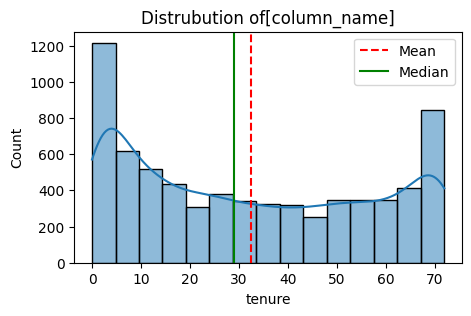

In [35]:
plot_histogram(df,"tenure")

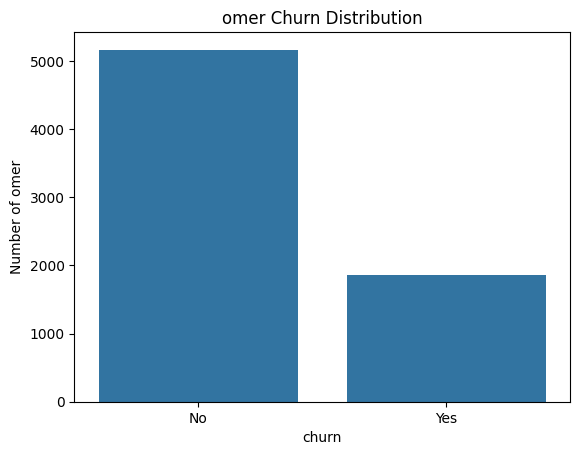

In [36]:
sns.countplot(x="Churn",data=df)
plt.title("omer Churn Distribution")
plt.xlabel("churn")
plt.ylabel("Number of omer")
plt.show()

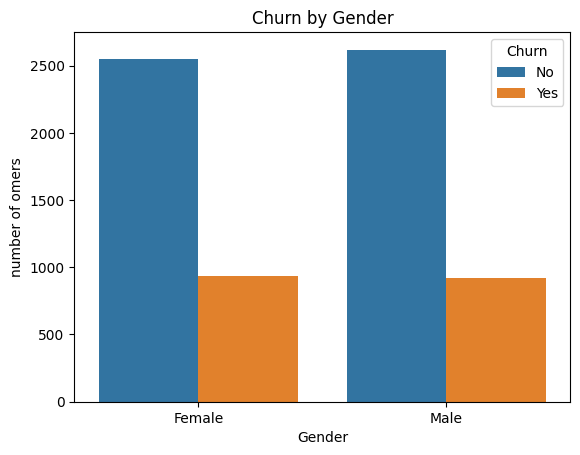

In [37]:
#Gender vs Churn 
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("number of omers")
plt.show()

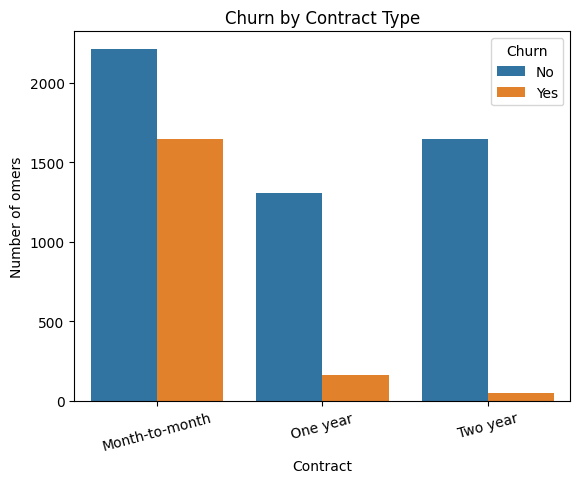

In [38]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of omers")
plt.xticks(rotation=15)
plt.show()

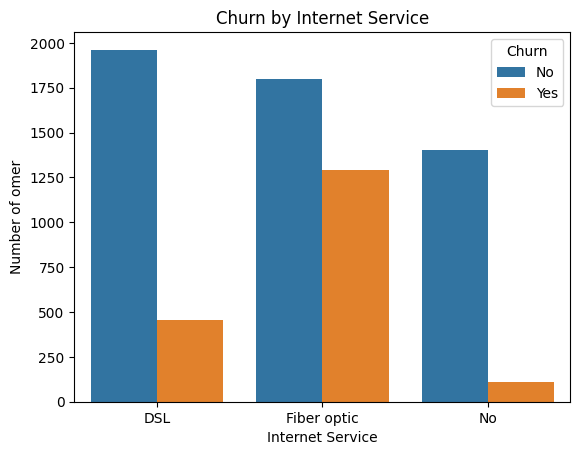

In [39]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of omer")
plt.show()

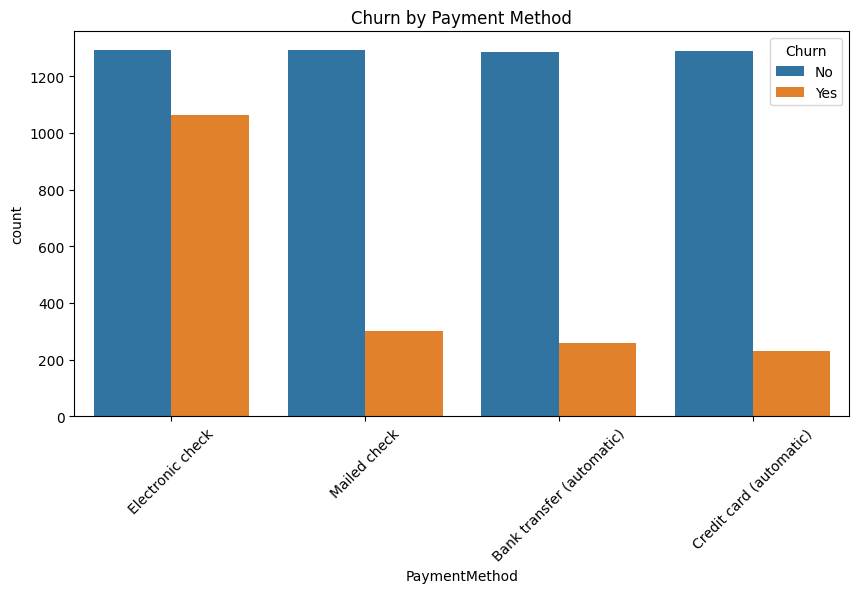

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

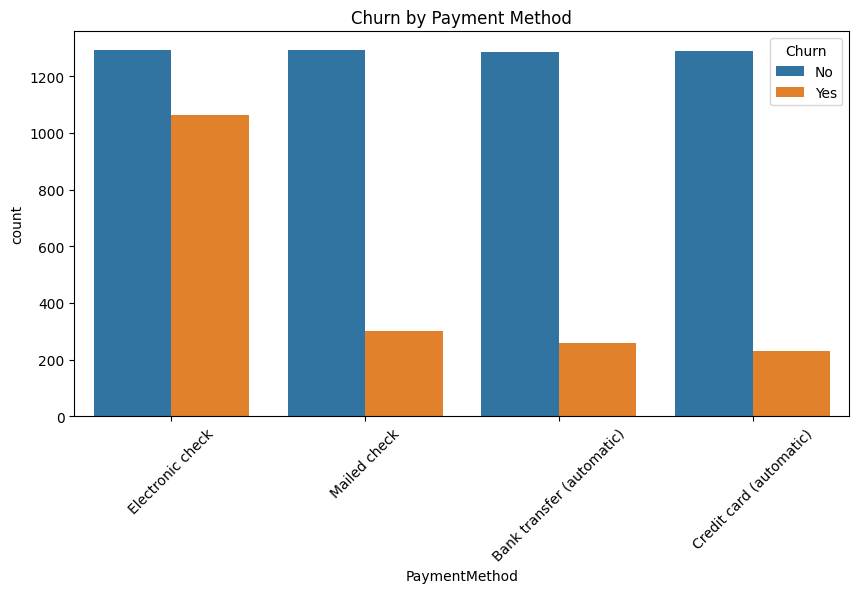

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

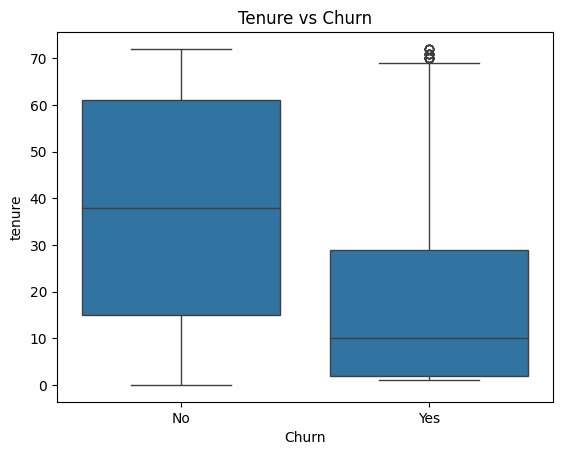

In [42]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

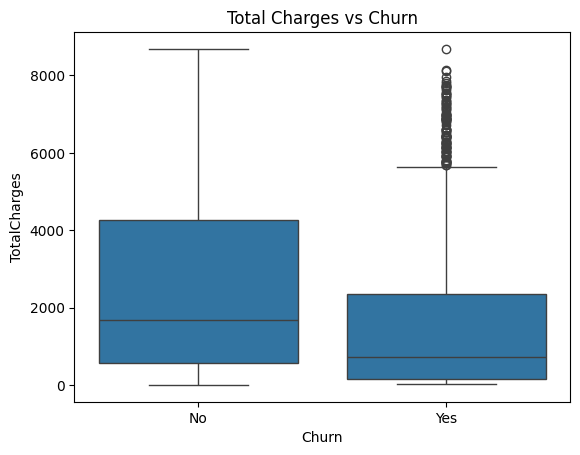

In [43]:
sns.boxplot(x="Churn",y="TotalCharges",data=df)
plt.title("Total Charges vs Churn")
plt.show()

In [44]:
df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [45]:
df['TotalCharges'].dtype

dtype('float64')

In [46]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

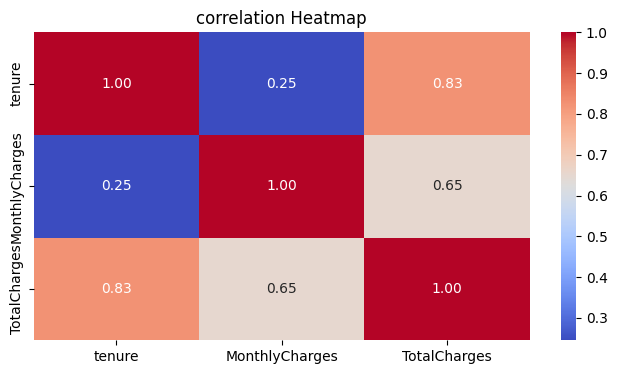

In [47]:
#correlation matrix -heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation Heatmap")
plt.show()

**categorical features analysis**

In [48]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

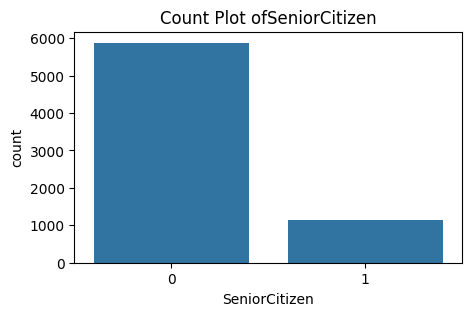

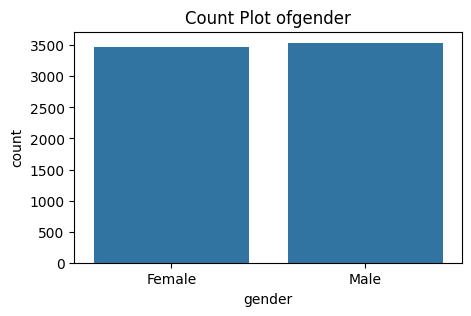

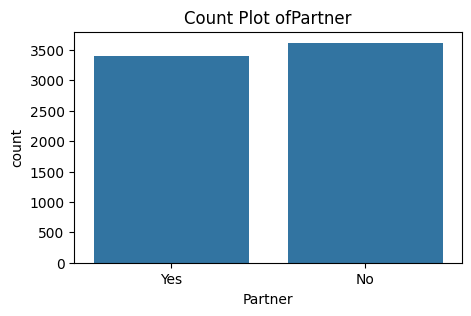

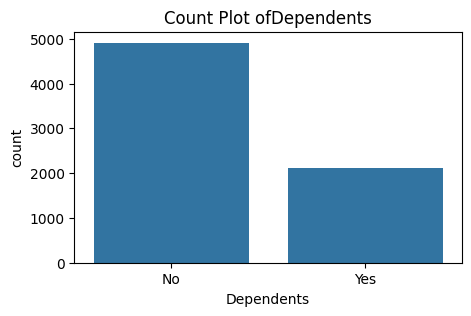

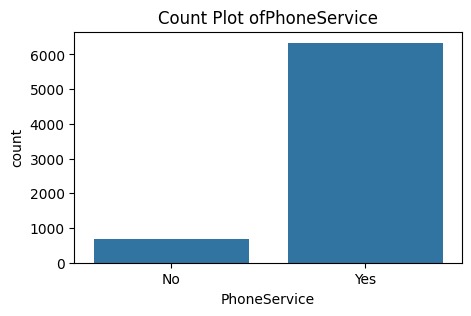

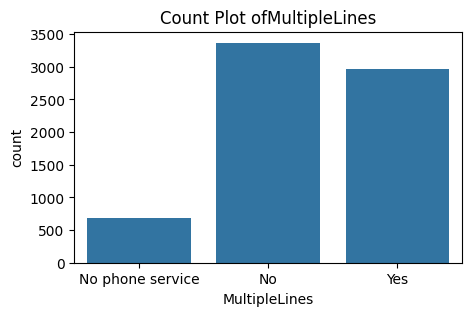

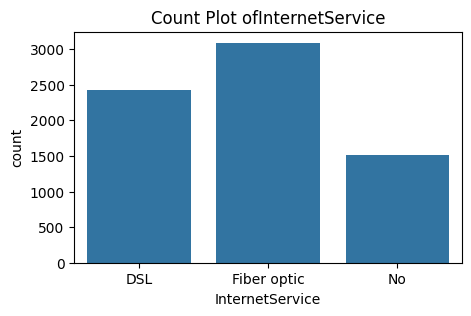

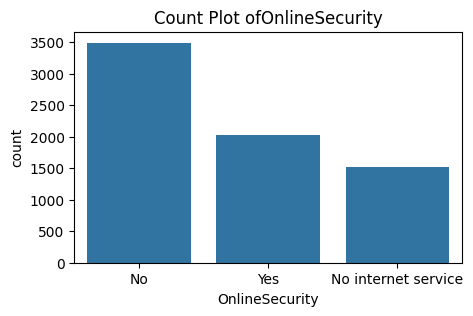

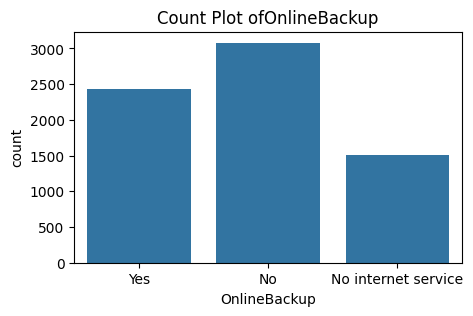

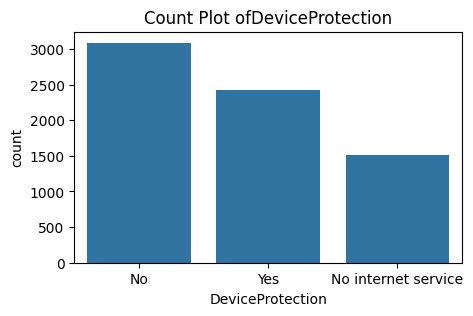

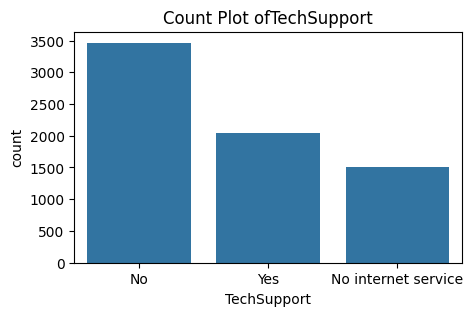

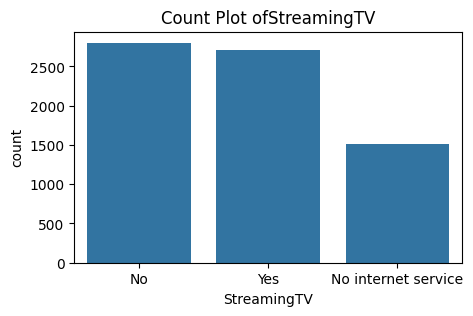

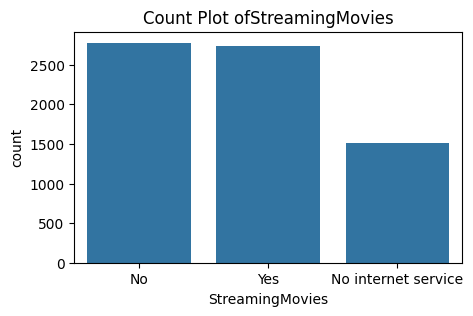

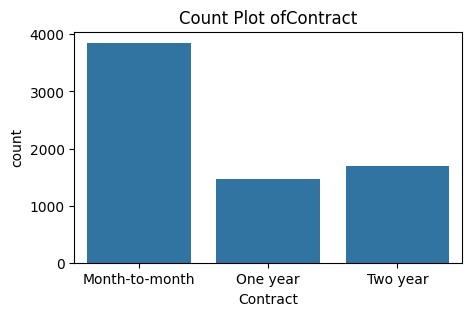

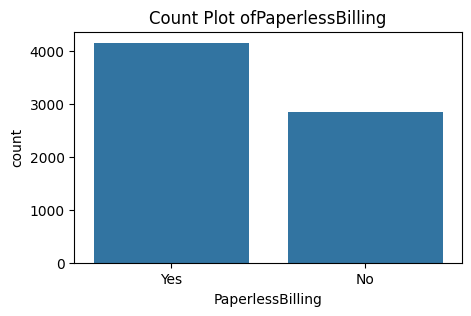

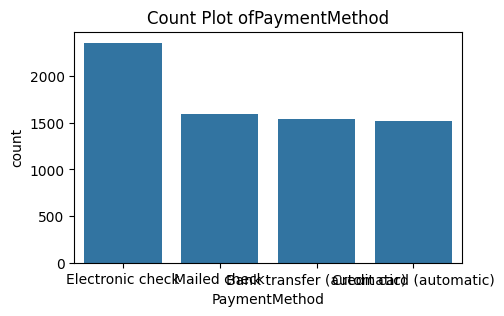

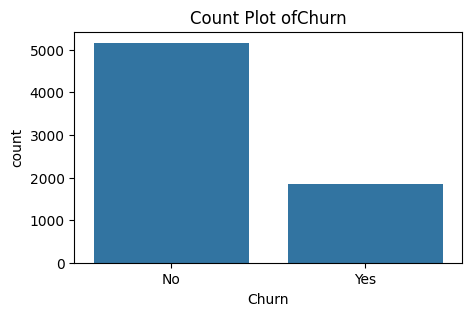

In [50]:
object_cols=df.select_dtypes(include="object").columns.to_list()
object_cols=["SeniorCitizen"]+object_cols
for col in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of{col}")
    plt.show()

In [51]:
df["Churn"]=df["Churn"].map({'No':0,'Yes':1})

In [52]:
df["Churn"].value_counts(dropna=False)

Churn
0    5164
1    1857
Name: count, dtype: int64

In [53]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [54]:
y.isnull().sum()

np.int64(0)

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.isnull().sum())

X shape: (7021, 19)
y shape: (7021,)
0


**5.Feature Encoding**

In [56]:
X=pd.get_dummies(X,drop_first=True)

In [57]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [58]:
X.shape

(7021, 30)

In [59]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

**6.Train/Test Split**

In [60]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [61]:
X.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [62]:
y.isnull().sum()

np.int64(0)

In [63]:
y.value_counts(dropna=False)

Churn
0    5164
1    1857
Name: count, dtype: int64

In [64]:
y=df["Churn"]

In [65]:
df["Churn"].isnull().sum()

np.int64(0)

In [66]:
df=df.dropna(subset=["Churn"])

In [67]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [68]:
df["Churn"].isnull().sum()

np.int64(0)

In [69]:
X.shape
y.shape

(7021,)

In [70]:
y.isnull().sum()

np.int64(0)

In [71]:
df['Churn'].value_counts(dropna=False)

Churn
0    5164
1    1857
Name: count, dtype: int64

In [72]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (5616, 30)
X_test: (1405, 30)
y_train: (5616,)
y_test: (1405,)


**7. Feature Scaling**

In [73]:
#feature scaling
from sklearn.preprocessing import StandardScaler

In [74]:
scaler=StandardScaler()

In [75]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

**8.Model Building**

In [76]:
# Logistic Regression

In [77]:
logistic_model=LogisticRegression(max_iter=1000)

In [78]:
print(y_train.value_counts())

Churn
0    4131
1    1485
Name: count, dtype: int64


In [79]:
print(y_train.unique())

[1 0]


In [80]:
y.value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

In [81]:
df['Churn'].value_counts(dropna=False)

Churn
0    5164
1    1857
Name: count, dtype: int64

In [82]:
df['Churn'].unique()

array([0, 1])

In [83]:
df['Churn'].head(20)

0     0
1     0
2     1
3     0
4     1
5     1
6     0
7     0
8     1
9     0
10    0
11    0
12    0
13    1
14    0
15    0
16    0
17    0
18    1
19    0
Name: Churn, dtype: int64

In [84]:
df.shape

(7021, 20)

In [85]:
df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

In [86]:
print(X_train.shape)
print(X_test.shape)
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

(5616, 30)
(1405, 30)
0
0


In [87]:
logistic_model.fit(X_train_scaled,y_train)

C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


LogisticRegression(max_iter=1000)

In [88]:
y_pred_lr=logistic_model.predict(X_test_scaled)

In [89]:
from sklearn.metrics import( accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report) 

In [90]:
print("Acurracy:",accuracy_score(y_test,y_pred_lr))
print("Precision:",precision_score(y_test,y_pred_lr))
print("Recall:",recall_score(y_test,y_pred_lr))
print("F1 score:",f1_score(y_test,y_pred_lr))

Acurracy: 0.80355871886121
Precision: 0.6621621621621622
Recall: 0.5268817204301075
F1 score: 0.5868263473053892


In [91]:
#logistic Regression confusion
cm_lr=confusion_matrix(y_test,y_pred_lr)

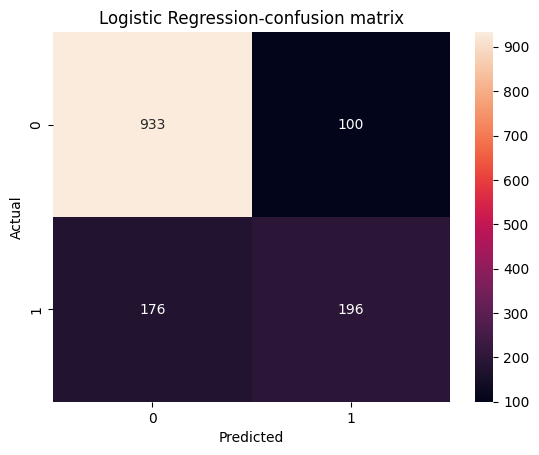

In [92]:
sns.heatmap(cm_lr,annot=True,fmt="d")
plt.title("Logistic Regression-confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**9.Now we are building second Model**

In [93]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)

In [95]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [96]:
y_pred_rf=rf_model.predict(X_test)

In [97]:
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Precission:",precision_score(y_test,y_pred_rf))
print("Recall:",recall_score(y_test,y_pred_rf))
print("F1 Score:",f1_score(y_test,y_pred_rf))

Accuracy: 0.7743772241992882
Precission: 0.6037735849056604
Recall: 0.43010752688172044
F1 Score: 0.5023547880690737


In [98]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1033
           1       0.60      0.43      0.50       372

    accuracy                           0.77      1405
   macro avg       0.71      0.66      0.68      1405
weighted avg       0.76      0.77      0.76      1405



In [99]:
#Confusion Matrix
cm_rf=confusion_matrix(y_test,y_pred_rf)

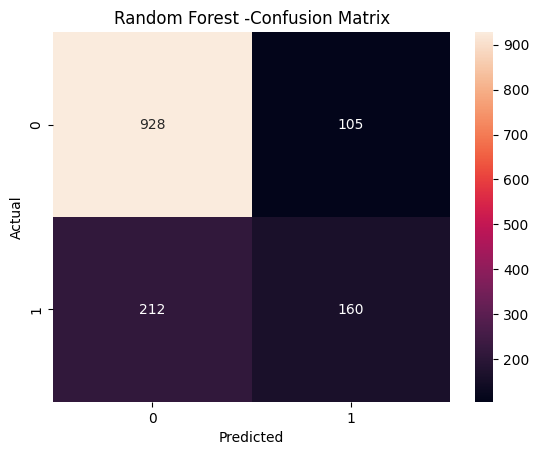

In [100]:
sns.heatmap(cm_rf,annot=True,fmt="d")
plt.title("Random Forest -Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**10.Now we are building Third Model**

**XGBoost**

In [101]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [102]:
from xgboost import XGBClassifier

In [103]:
xgb_model=XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,random_state=42,eval_metric="logloss")

In [104]:
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [105]:
#prediction 
y_pred_xgb=xgb_model.predict(X_test)

In [106]:
print("Accurray:",accuracy_score(y_test,y_pred_xgb))
print("Precision:",precision_score(y_test,y_pred_xgb))
print("Recall:",recall_score(y_test,y_pred_xgb))
print("F1 Score:",f1_score(y_test,y_pred_xgb))

Accurray: 0.802846975088968
Precision: 0.6643598615916955
Recall: 0.5161290322580645
F1 Score: 0.5809379727685325


In [107]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



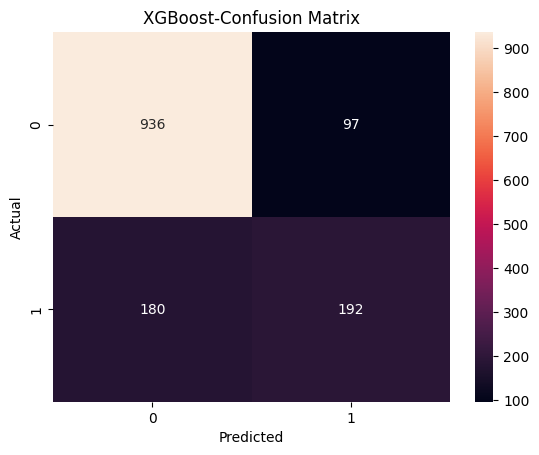

In [108]:
cm_xgb=confusion_matrix(y_test,y_pred_xgb)
sns.heatmap(cm_xgb,annot=True,fmt="d")
plt.title("XGBoost-Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**11.Model Comparison**

In [109]:
# now,are comparing all three Models

In [110]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803559,0.662162,0.526882,0.586826
1,Random Forest,0.774377,0.603774,0.430108,0.502355
2,XGBoost,0.802847,0.664360,0.516129,0.580938


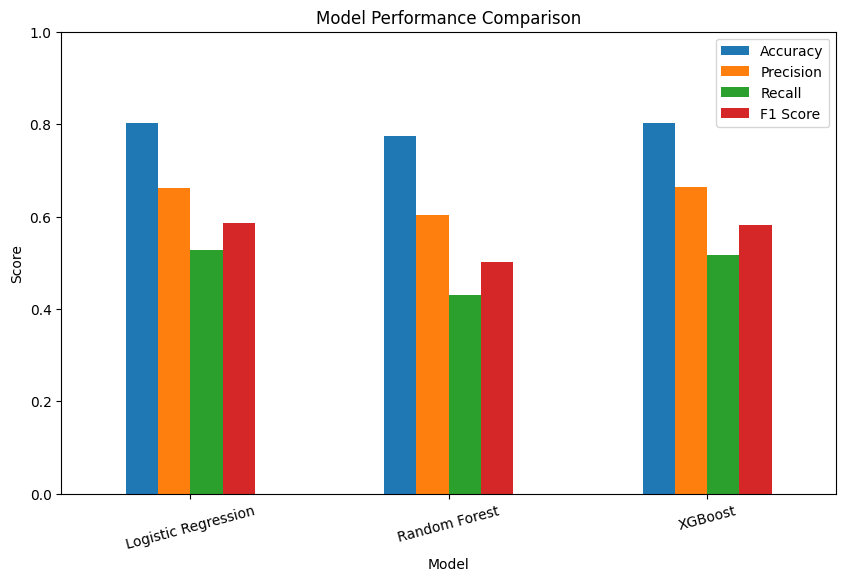

In [111]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

**12.Cross validation**

In [112]:
from sklearn.model_selection import cross_val_score

In [113]:
lr_cv=cross_val_score(logistic_model,X_train_scaled,y_train,cv=5,scoring="accuracy")
print("logistic Regression CV scores:",lr_cv)
print("Mean CV Accuracy:",lr_cv.mean())

C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


logistic Regression CV scores: [0.81939502 0.80053428 0.80231523 0.80053428 0.80231523]
Mean CV Accuracy: 0.8050188076548899


C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\Anchal\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [114]:
#Random forest 
rf_cv=cross_val_score(rf_model,X_train,y_train,cv=5,scoring="accuracy")
print("Random Forest CV scores:",rf_cv)
print("Mean CV Accuracy :",rf_cv.mean())

Random Forest CV scores: [0.78558719 0.78984862 0.80142476 0.77649154 0.78361532]
Mean CV Accuracy : 0.7873934840269614


In [115]:
# xgboost
xgb_cv=cross_val_score(xgb_model,X_train,y_train,cv=5,scoring="accuracy")
print("XGBoost CV Scores:",xgb_cv)
print("Mean CV Accuarcy:",xgb_cv.mean())

XGBoost CV Scores: [0.81049822 0.809439   0.81032947 0.7969724  0.79073909]
Mean CV Accuarcy: 0.8035956370043383


**13.Best model finding**

In [116]:
#Now we are finding best Model
best_model_name=results.loc[results["F1 Score"].idxmax(),"Model"]
print("Best Model:",best_model_name)

Best Model: Logistic Regression


In [117]:
#Now we are storing best Model into variable 
if best_model_name == "Logistic Regression":
    best_model =logistic_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = xgb_model
print("Best  model selected :",best_model_name)

Best  model selected : Logistic Regression


**14.Model Saving**

In [118]:
import joblib

In [119]:
joblib.dump(best_model,"customer_churn_model.pk1")

['customer_churn_model.pk1']

In [120]:
#feature columns save
joblib.dump(X.columns.tolist(),"model_columns.pk1")

['model_columns.pk1']

In [121]:
joblib.dump(scaler,"scaler.pk1")

['scaler.pk1']

In [122]:
joblib.dump(best_model,"customer_churn_model.pk1")

['customer_churn_model.pk1']

In [123]:
joblib.dump(X_train.columns.tolist(),"model_columns.pk1")

['model_columns.pk1']

In [124]:
joblib.dump(scaler,"scaler.pk1")

['scaler.pk1']

**15.Conclusion**

This project is successfully developed a Machine Learning based Customer Churn Prediction system.Different models including Logistic Regression ,Random Forest,and XGBoost were trained and evaluated .The results show that machine learning can help identify customers who are likely to churn and supported better customer retention decisions

In [125]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.streamlit', '.th-client', '.vscode', '.vscode-shared', '1-d.py', '19.py', '3d to 1 d.py', 'airports.json', 'anchal-1.c', 'app.py', 'AppData', 'Application Data', 'archive (1).zip', 'arguments.py', 'arr.py', 'arr1.py', 'array.py', 'arrayin.py', 'average numbers.py', 'average.py', 'batsman_season_record (1).csv', 'batsman_season_record.csv', 'binary search', 'broadcasting.py', 'charts.py', 'cleaned_Deliveries.csv', 'code.cpp', 'code.exe', 'Contacts', 'Cookies', 'customer_churn.ipynb', 'customer_churn_model.pk1', 'customer_churn_model.pkl', 'data frame.py', 'data mean.py', 'data.csv', 'deliveries.csv', 'Demo.ipynb', 'Demo1.ipynb', 'dictionary integer.py', 'dictionay.py', 'dictn.py', 'Documents', 'Downloads', 'Dream11_project.ipynb', 'dsa 2', 'dsa1', 'dtype.py', 'dupl.py', 'duplicates item.py', 'duplicates.py', 'duplicates2.py', 'even or odd.py', 'factorial.py', 'Fant

In [126]:
print(X_train.columns)
print(len(X_train.columns))

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')
30


In [127]:
import os
print(os.getcwd())

C:\Users\Anchal


In [128]:
import os
print(os.path.abspath("customer_churn.ipynb"))

C:\Users\Anchal\customer_churn.ipynb


In [129]:
import os

print(os.path.abspath("customer_churn.ipynb"))
print(os.path.abspath("customer_churn_model.pkl"))
print(os.path.abspath("model_columns.pkl"))
print(os.path.abspath("scaler.pkl"))

C:\Users\Anchal\customer_churn.ipynb
C:\Users\Anchal\customer_churn_model.pkl
C:\Users\Anchal\model_columns.pkl
C:\Users\Anchal\scaler.pkl


In [130]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [131]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [132]:
columns=joblib.load("model_columns.pk1")
print(columns)
print(columns[:10])
print(len(columns))

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes']
30


In [133]:
print(best_model)

LogisticRegression(max_iter=1000)
